# NB02 — Mary's biopsy and the Process-Role-Object pattern
## Naming participants without inventing new properties

On 2026-02-25 Mary returns to the clinic for a **core needle biopsy of the left breast**. A radiologist, holding a biopsy needle, removes a small cylinder of tissue from her left breast. After the procedure, five participants are involved:

1. **Mary** — the *subject* on whom the procedure is performed
2. **The radiologist** — the *agent* who plans and executes the procedure
3. **The biopsy needle** — the *instrument* that mediates the procedure
4. **The left breast** — the *location* at which the procedure occurs
5. **The tissue specimen** — the *output* that did not exist before the procedure began

The temptation is to invent five properties — `hasSubject`, `hasAgent`, `hasInstrument`, `hasLocation`, `hasOutput` — and litter the ontology with them. SULO takes the opposite route: **a single participation property**, `sulo:hasParticipant`, and the typing of *how* an entity participates is moved into a reified intermediate — the **Role**. This is the Process-Role-Object (PRO) design pattern, and Mary's biopsy is the canonical example.


## Learning objectives

1. Understand why SULO offers only one participation property and how role reification recovers the expressivity of many role-specific properties
2. Import the PRO ontology (role taxonomy + two process subtypes) without adding any new object or data property to the MIE ontology
3. Type the participants of `SCT_CoreNeedleBiopsyOfBreast` at the *class level* using nested existential restrictions over `sulo:hasParticipant` and `sulo:isFeatureOf`
4. Define an equivalent class `SpecimenProducingProcedure` that classifies any transformation process whose output is a tissue specimen
5. Distinguish **persistent roles** (one individual per bearer, reused across many processes) from **event-bound roles** (one individual per process), and apply both correctly to Mary's individual biopsy
6. Contrast a `TransformationProcess` (biopsy) with a `DevelopmentalProcess` (follow-up visit), reusing Mary's persistent patient role across both


## Setting up

We reload SULO, load the PRO ontology, and reload the MIE checkpoint produced by NB1. Then we declare PRO as an imported ontology of MIE so that PRO classes are first-class citizens of subsequent axioms.

In [1]:
import sys, os, datetime
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append("dist")

sulo = get_ontology("dist/sulo.owl").load()
pro  = get_ontology("dist/pro.owl").load()
mie  = get_ontology("dist/mie-01.owl").load()
mie.imported_ontologies.append(pro)

print("PRO classes available for the PRO pattern:")
for c in sorted(pro.classes(), key=lambda c: c.name):
    parents = [p.name for p in c.is_a if hasattr(p, 'name')]
    print(f"  {c.name:25s} <- {parents}")

PRO classes available for the PRO pattern:
  AgentRole                 <- ['Role']
  ConsumedRole              <- ['PatientRole']
  DevelopmentRole           <- ['PatientRole']
  DevelopmentalProcess      <- ['Process']
  EmergingRole              <- ['Role']
  InstrumentRole            <- ['Role']
  LocationRole              <- ['Role']
  PatientRole               <- ['Role']
  PersistingRole            <- ['Role']
  TransformationProcess     <- ['Process']


## §1 — Why a single participation property?

Most clinical ontologies you will encounter use many participation properties: `hasPerformer`, `hasInstrument`, `hasAnatomicalSite`, `hasResult`, `hasSubject`, `hasReason`, … Every new procedure type that introduces a new kind of participant creates pressure to mint a new property. The result is *vocabulary sprawl*: hundreds of properties whose intended meanings overlap and whose alignment across institutions becomes a permanent maintenance burden.

SULO takes a different stance. Every participant of a process is linked via the **single** property `sulo:hasParticipant`. Distinguishing *how* the entity participates is the job of an intermediate **Role** entity: the role is `sulo:isFeatureOf` the object that plays it, and the role's *type* (Agent, Instrument, Location, …) carries the participation semantics.

Concretely, the participation pattern reads as follows:

```
process  --sulo:hasParticipant-->  role  --sulo:isFeatureOf-->  object
```

Two relations, one pattern, arbitrarily many role *types*. New role types are introduced as classes — not as properties — and so the ontology's property vocabulary stays small even as its domain coverage grows. This is the move that lets a clinical ontology stay aligned with SULO without bringing in a thicket of domain-specific properties.

## §2 — What PRO offers

The PRO ontology (`https://w3id.org/ontostart/pro/`) bundles the role taxonomy plus two process subtypes that capture *what happens to participants*. The whole vocabulary, printed by the setup cell above, is:

| Class | Parent | Semantics |
|---|---|---|
| `AgentRole` | `sulo:Role` | Intentional initiator and controller of the process |
| `PatientRole` | `sulo:Role` | Undergoer of the effects of the process |
| `ConsumedRole` | `PatientRole` | Ceases to exist during the process |
| `EmergingRole` | `sulo:Role` | Comes into existence during the process |
| `PersistingRole` | `sulo:Role` | Persists unchanged across the process |
| `InstrumentRole` | `sulo:Role` | Mediates or enables the process, triggered by an agent |
| `LocationRole` | `sulo:Role` | The spatial region in which the process occurs |
| `TransformationProcess` | `sulo:Process` | At least one participant is consumed and/or an output emerges |
| `DevelopmentalProcess` | `sulo:Process` | Participants persist; only their qualities or types change |

## §3 — Naming the participants

Before we can write the class-level restrictions for the biopsy, we need *names* for the participating objects. Four placeholder `sulo:SpatialObject` sub-classes suffice for now:

- `Person` — a human individual
- `BiopsyNeedle` — the instrument
- `Breast` — the anatomical site
- `Tissue` — a fragment of biological material (the *kind* of matter, irrespective of how it is used)

Notice what we *do not* declare:

- **`Physician` is not a sub-class of `Person`**. A person can train, practise, retire, re-qualify — their physician-hood is contingent, not necessary.
- **`TissueSpecimen` is not a sub-class of `Tissue`**. A piece of tissue can be extracted with diagnostic intent, then re-purposed for research, archived, or disposed of — its specimen-status comes and goes while the tissue persists.

Both temptations would silently commit the ontology to "necessarily, always, X". §5 makes this clean by pushing the contingent typing — physician-hood, specimen-hood — into anti-rigid *roles* that rigid kinds bear.

In [2]:
with mie:
    class Person(sulo.SpatialObject):
        """A human individual."""
        label = [locstr("person", "en")]

    class BiopsyNeedle(sulo.SpatialObject):
        """A hollow needle designed to extract a cylindrical core of tissue from a biological structure."""
        label = [locstr("biopsy needle", "en")]

    class Breast(sulo.SpatialObject):
        """A mammary gland with associated adipose tissue, skin, and nipple — internal structure is added in NB3."""
        label = [locstr("breast", "en")]

    class Tissue(sulo.SpatialObject):
        """A fragment of biological material — the rigid kind, irrespective of how it is currently used."""
        label = [locstr("tissue", "en")]

print(f"MIE classes now: {len(list(mie.classes()))}")
print(f"MIE object properties (local): {len(list(mie.object_properties()))}  ← still zero")

MIE classes now: 15
MIE object properties (local): 0  ← still zero


## §4 — Specialising PRO roles for clinical use

PRO's role taxonomy (`PatientRole`, `AgentRole`, `InstrumentRole`, …) is upper-level — it answers *what kind of participation*. For a clinical ontology we want a more domain-specific vocabulary that names the same roles in their clinical guise.

Two sub-classes are enough to make the pattern visible:

- `SubjectOfCareRole` `SubClassOf` `pro:PatientRole` — the patient as a subject undergoing diagnostic or therapeutic care.
- `CareProviderRole`  `SubClassOf` `pro:AgentRole`   — a clinician (physician, nurse, allied professional) who plans or executes the procedure.

The MIE-specific names sit *under* the PRO names, so any restriction over `pro:PatientRole` is automatically satisfied by an individual typed `SubjectOfCareRole`. The specialisation buys clinical legibility without breaking the upper-level commitments — and any subsequent reasoning step that targets the PRO names still picks up the MIE-specialised individuals through standard sub-class inference.

In [3]:
with mie:
    class SubjectOfCareRole(pro.PatientRole):
        """The patient as a subject undergoing diagnostic or therapeutic care."""
        label = [locstr("subject-of-care role", "en")]

    class CareProviderRole(pro.AgentRole):
        """A clinician (physician, nurse, allied professional) who plans or executes the procedure."""
        label = [locstr("care-provider role", "en")]

print("Clinical role specialisations:")
for c in [SubjectOfCareRole, CareProviderRole]:
    parent = next(p for p in c.is_a if hasattr(p, 'name'))
    print(f"  - mie:{c.name} SubClassOf pro:{parent.name}")

Clinical role specialisations:
  - mie:SubjectOfCareRole SubClassOf pro:PatientRole
  - mie:CareProviderRole SubClassOf pro:AgentRole


## §5 — Rigid kinds vs anti-rigid roles (an OntoClean clean-up)

OntoClean (Guarino & Welty) tags every class with **rigidity** (R) or **anti-rigidity** (~R):

- **Rigid** — every instance is *necessarily* an instance for as long as it exists. `Person`, `Tissue` are rigid.
- **Anti-rigid** — every instance *could* not be an instance and still exist. `Patient`, `Physician`, `Specimen` are anti-rigid: the kind is *played* for a phase of life.

OntoClean forbids `~R` `SubClassOf:` `R`. A sub-class of a rigid parent inherits rigidity — so writing `class Physician(Person)` or `class TissueSpecimen(Tissue)` would commit the ontology to "necessarily, always, a physician" / "necessarily, always, a specimen", which is wrong in both cases.

The SULO/PRO-native fix: push the contingent typing into a **role** the rigid bearer plays.

```
Class: PhysicianRole       SubClassOf: CareProviderRole
Class: RadiologistRole     SubClassOf: PhysicianRole
Class: GynecologistRole    SubClassOf: PhysicianRole

Class: SpecimenRole        SubClassOf: pro:PatientRole
```

Two parallel examples land the rule:

| Rigid kind | Anti-rigid role |
|---|---|
| `Person`  | `PhysicianRole`, `RadiologistRole`, `GynecologistRole` |
| `Tissue`  | `SpecimenRole` |

The role classes are anti-rigid — a `SpecimenRole` individual exists only while its bearer is standing in as a sample for examination, archival, or analysis. The bearer remains a rigid `Tissue`. Clinical specialisation and event-relative typing accumulate *in the role hierarchy*, not by tightening the kind of matter.

(There is an alternative profession-modelling pattern — `Profession` as a separate entity that a `Person` `hasQualification` — common in OBI. It is heavier and does not earn anything new for this tutorial, so we set it aside.)

In [4]:
with mie:
    class PhysicianRole(CareProviderRole):
        """The role a person plays while qualified and authorised to practise medicine."""
        label = [locstr("physician role", "en")]

    class RadiologistRole(PhysicianRole):
        """A physician role specialised to diagnostic imaging."""
        label = [locstr("radiologist role", "en")]

    class GynecologistRole(PhysicianRole):
        """A physician role specialised to gynaecologic care."""
        label = [locstr("gynecologist role", "en")]

    class SpecimenRole(pro.PatientRole):
        """The role a piece of tissue bears while standing in as a sample to be examined, archived, or analysed."""
        label = [locstr("specimen role", "en")]

print("Anti-rigid role hierarchy:")
for c in [CareProviderRole, PhysicianRole, RadiologistRole, GynecologistRole, SpecimenRole]:
    parent = next(p for p in c.is_a if hasattr(p, 'name'))
    print(f"  - mie:{c.name} SubClassOf {parent.namespace.name}:{parent.name}")

Anti-rigid role hierarchy:
  - mie:CareProviderRole SubClassOf pro:AgentRole
  - mie:PhysicianRole SubClassOf mie-01:CareProviderRole
  - mie:RadiologistRole SubClassOf mie-01:PhysicianRole
  - mie:GynecologistRole SubClassOf mie-01:PhysicianRole
  - mie:SpecimenRole SubClassOf pro:PatientRole


## §6 — Class-level role typing of the biopsy

We now express the *necessary* conditions for being a `SCT_CoreNeedleBiopsyOfBreast`. Two things happen in this cell.

**1. We add `pro:TransformationProcess` as a parent.** A biopsy is the canonical transformation: the tissue specimen does not exist before the procedure begins and does exist after it ends. This single sub-class axiom carries the ontological commitment that *something emerges*.

**2. We add five `is_a` restrictions** — one per participant kind — each of the form

```
hasParticipant some ( <RoleType> and isFeatureOf some <ObjectType> )
```

These are **necessary** conditions, not sufficient: every biopsy *must* have these five participants, but having all five does not by itself make a process a biopsy. (For sufficient conditions we would use `equivalent_to`, as we do for the defined class in §5.)

In [5]:
with mie:
    mie.SCT_CoreNeedleBiopsyOfBreast.is_a.append(pro.TransformationProcess)
    mie.SCT_CoreNeedleBiopsyOfBreast.is_a.extend([
        sulo.hasParticipant.some(SubjectOfCareRole  & sulo.isFeatureOf.some(Person)),
        sulo.hasParticipant.some(RadiologistRole    & sulo.isFeatureOf.some(Person)),
        sulo.hasParticipant.some(pro.InstrumentRole & sulo.isFeatureOf.some(BiopsyNeedle)),
        sulo.hasParticipant.some(pro.LocationRole   & sulo.isFeatureOf.some(Breast)),
        sulo.hasParticipant.some(pro.EmergingRole   & sulo.isFeatureOf.some(Tissue)),
    ])

print("SCT_CoreNeedleBiopsyOfBreast restrictions:")
for r in mie.SCT_CoreNeedleBiopsyOfBreast.is_a:
    print(f"  - {manchester(r) if hasattr(r, 'property') else r.name if hasattr(r,'name') else r}")

SCT_CoreNeedleBiopsyOfBreast restrictions:
  - Process
  - TransformationProcess
  - hasParticipant some (SubjectOfCareRole and isFeatureOf some Person)
  - hasParticipant some (RadiologistRole and isFeatureOf some Person)
  - hasParticipant some (InstrumentRole and isFeatureOf some BiopsyNeedle)
  - hasParticipant some (LocationRole and isFeatureOf some Breast)
  - hasParticipant some (EmergingRole and isFeatureOf some Tissue)


## §7 — A defined class: `SpecimenProducingProcedure`

The five necessary conditions on the biopsy let us identify a more general class: *any* transformation process whose output is **tissue extracted with specimen-intent** would satisfy them. We define it as an **equivalent class** — necessary *and* sufficient (Manchester syntax):

```
Class: SpecimenProducingProcedure
  EquivalentTo:
    TransformationProcess
      and (hasParticipant some
            (EmergingRole and
              (isFeatureOf some
                (Tissue and (hasFeature some SpecimenRole)))))
```

The nested existential reads: *the EmergingRole's bearer is Tissue that also bears a SpecimenRole*. That second `hasFeature some SpecimenRole` is what distinguishes a biopsy-style extraction from any other procedure that happens to produce tissue — a tonsillectomy, say, produces tissue but typically without specimen-intent.

Any individual that satisfies the condition will be **classified** by the reasoner as a `SpecimenProducingProcedure`. Mary's biopsy will be one. So will a punch biopsy, a fine-needle aspirate, a surgical excision-with-pathology. The defined class becomes a *clinical capability* in the ontology — retrieve every record event whose extracted tissue is destined for examination, without enumerating procedure types.

In [6]:
with mie:
    class SpecimenProducingProcedure(sulo.Process):
        """A transformation process whose output is tissue bearing a SpecimenRole — i.e., tissue extracted with diagnostic intent."""
        label = [locstr("specimen-producing procedure", "en")]
        equivalent_to = [
            pro.TransformationProcess &
            sulo.hasParticipant.some(
                pro.EmergingRole & sulo.isFeatureOf.some(
                    Tissue & sulo.hasFeature.some(SpecimenRole)
                )
            )
        ]

print("Class: SpecimenProducingProcedure")
print("  EquivalentTo:")
for r in SpecimenProducingProcedure.equivalent_to:
    print(f"    {manchester(r)}")

Class: SpecimenProducingProcedure
  EquivalentTo:
    TransformationProcess and (hasParticipant some (EmergingRole and (isFeatureOf some (Tissue and hasFeature some SpecimenRole))))


## §8 — Persistent roles vs event-bound roles

Before instantiating Mary's biopsy, we must answer a question that decides how many role individuals we create.

> *Does Mary have **one** patient role that participates in many processes, or **one new patient role per process**?*

Both readings are formally compatible with PRO. The pattern `process hasParticipant role; role isFeatureOf object` does not constrain whether a single role-individual may participate in many processes. So this is a **modelling choice**, not a logical one — and the right answer depends on whether the role's *bearer* persists.

### Persistent roles (one individual per bearer)

When the bearer of a role persists across the care episode, the role is best modelled as a *disposition* of that bearer that gets realised in many process participations. One role individual; many processes `hasParticipant` it. This applies to:

- **Mary's `PatientRole`** — Mary is the subject of care throughout her odyssey. Creating nine patient-role individuals (one per event) would individuate without purpose.
- **Each clinician's `AgentRole`** — Dr Miller's agency as the radiologist persists across the procedures he performs; Dr Smith's agency as the gynecologist persists across the visits she conducts.

### Event-bound roles (one individual per process)

When the bearer is itself event-specific, or when the role's standing is intrinsically tied to one process, the role must be event-bound. This applies to:

- **The specimen's `EmergingRole`** — the specimen comes into existence *in this biopsy*; the role cannot precede its bearer.
- **The needle's `InstrumentRole`** — the needle is a sterile single-use instrument; it has no other procedural standing.
- **The breast's `LocationRole`** — Mary's breast persists, but its standing as *location of this particular biopsy* is contextual to that one event. Other processes will involve the same breast playing other location-roles.

### A naming convention

We adopt a visible convention so the choice is legible in any individual name:

- **persistent** → no date suffix: `mary_patient_role`, `miller_agent_role`, `smith_agent_role`
- **event-bound** → date suffix tagging the process: `specimen_emerging_role_feb25`, `needle_instrument_role_feb25`, `breast_location_role_feb25`

This is the conventional shape for clinical-informatics ontologies modelled on SULO. It also yields a much smaller A-Box — Mary's nine encounters share one patient role, not nine.

## §9 — Mary's individual biopsy

We now create the participating individuals and the five role individuals that connect them to `mary_biopsy_feb25`. The patient and agent roles use the **persistent** convention (no suffix); the instrument, location, and emerging roles use the **event-bound** convention (suffix `_feb25`). The biopsy's `hasParticipant` list links all five roles to the process; no new property is introduced anywhere.

In [7]:
# Persistent bearers + persistent roles (re-usable across processes)
mary_biopsy = mie.mary_biopsy_feb25

with mie:
    mary             = Person("mary")
    mary.label       = [locstr("Mary", "en")]
    dr_miller        = Person("dr_miller")
    dr_miller.label  = [locstr("Dr. Miller, radiologist", "en")]
    mary_left_breast = Breast("mary_left_breast")

    mary_patient_role = SubjectOfCareRole("mary_patient_role")
    mary_patient_role.isFeatureOf = [mary]

    miller_agent_role = RadiologistRole("miller_agent_role")
    miller_agent_role.isFeatureOf = [dr_miller]


In [8]:
# Event-bound bearers + event-bound emerging role.
# The tissue is created in the biopsy event but persists afterward and bears
# an enduring SpecimenRole — its standing as a sample for examination.
with mie:
    needle_feb25      = BiopsyNeedle("biopsy_needle_feb25")
    mary_tissue_feb25 = Tissue("mary_tissue_feb25")

    needle_instrument_role_feb25 = pro.InstrumentRole("needle_instrument_role_feb25")
    needle_instrument_role_feb25.isFeatureOf = [needle_feb25]

    breast_location_role_feb25 = pro.LocationRole("breast_location_role_feb25")
    breast_location_role_feb25.isFeatureOf = [mary_left_breast]

    # Event-bound: this role exists only inside the biopsy that creates the tissue
    specimen_emerging_role_feb25 = pro.EmergingRole("specimen_emerging_role_feb25")
    specimen_emerging_role_feb25.isFeatureOf = [mary_tissue_feb25]

    # Persistent: the tissue continues to bear specimen-status across later examinations
    mary_specimen_role = SpecimenRole("mary_specimen_role")
    mary_specimen_role.isFeatureOf = [mary_tissue_feb25]


In [9]:
# Combine: the biopsy has five participants — two persistent, three event-bound
with mie:
    mary_biopsy.hasParticipant = [
        mary_patient_role,
        miller_agent_role,
        needle_instrument_role_feb25,
        breast_location_role_feb25,
        specimen_emerging_role_feb25,
    ]

print("Mary's biopsy participants:")
for r in mary_biopsy.hasParticipant:
    role_type = [c.name for c in r.is_a if hasattr(c, 'name')][0]
    bearer = [b.name for b in r.isFeatureOf][0]
    kind = "persistent" if "_feb25" not in r.name else "event-bound"
    print(f"  - {r.name:35s} ({role_type:15s}, {kind:12s}) isFeatureOf {bearer}")


Mary's biopsy participants:
  - mary_patient_role                   (SubjectOfCareRole, persistent  ) isFeatureOf mary
  - miller_agent_role                   (RadiologistRole, persistent  ) isFeatureOf dr_miller
  - needle_instrument_role_feb25        (InstrumentRole , event-bound ) isFeatureOf biopsy_needle_feb25
  - breast_location_role_feb25          (LocationRole   , event-bound ) isFeatureOf mary_left_breast
  - specimen_emerging_role_feb25        (EmergingRole   , event-bound ) isFeatureOf mary_tissue_feb25


## §10 — Run the reasoner: classification under the defined class

Two consequences are expected after reasoning.

1. **Consistency**: the five `hasParticipant.some(...)` necessary conditions on `SCT_CoreNeedleBiopsyOfBreast` are satisfied by `mary_biopsy_feb25` (we asserted all five). The reasoner reports no inconsistent classes.
2. **Classification**: `mary_biopsy_feb25` satisfies the equivalent-class condition for `SpecimenProducingProcedure` (it is a `TransformationProcess` and one of its participants is an `EmergingRole` `isFeatureOf` a `Tissue`). The reasoner should therefore include `mary_biopsy_feb25` in `SpecimenProducingProcedure.instances()`.

In [10]:
result = safe_call_reasoner(mie)
print("Reasoner ok:           ", result["ok"])
print("Inconsistent classes:  ", result["inconsistent"])

print("\nInstances of SpecimenProducingProcedure (asserted + inferred):")
for ind in SpecimenProducingProcedure.instances():
    print(f"  - {ind.name}")

Reasoner ok:            True
Inconsistent classes:   []

Instances of SpecimenProducingProcedure (asserted + inferred):
  - mary_biopsy_feb25


## §11 — Contrast: the follow-up visit as a `DevelopmentalProcess`

Eight months later, Mary returns for a follow-up visit with her gynecologist Dr Smith. Structurally the encounter is quite different from the biopsy:

- Nothing material is created or destroyed.
- Mary persists as the same individual; only her *qualities* (the state of her disease, modelled in NB5) may change.
- No instrument is introduced for the express purpose of mediating a transformation.

This is the canonical shape of a `pro:DevelopmentalProcess`. We assign the parent type, add only the two role-typed restrictions that *do* apply (a patient and an agent), and assert just those two participants on `mary_followup_sep30`. There is no `EmergingRole`, no `ConsumedRole` — and that absence is itself the lesson.

Crucially, we **reuse `mary_patient_role`** — Mary's persistent patient-role disposition, already created in §7. We introduce **a new persistent agent role** for Dr Smith, who is a different clinician from Dr Miller.

In [11]:
# Class-level role typing of the follow-up visit
with mie:
    mie.SCT_FollowUpVisit.is_a.append(pro.DevelopmentalProcess)
    mie.SCT_FollowUpVisit.is_a.extend([
        sulo.hasParticipant.some(SubjectOfCareRole & sulo.isFeatureOf.some(Person)),
        sulo.hasParticipant.some(GynecologistRole  & sulo.isFeatureOf.some(Person)),
    ])


In [12]:
# A new persistent bearer (Dr Smith) and her persistent gynecologist role
with mie:
    dr_smith = Person("dr_smith")
    dr_smith.label = [locstr("Dr. Smith, gynecologist", "en")]

    smith_agent_role = GynecologistRole("smith_agent_role")
    smith_agent_role.isFeatureOf = [dr_smith]

    # Mary's follow-up: reuse her persistent subject-of-care role; new gynecologist role for Dr Smith
    mie.mary_followup_sep30.hasParticipant = [
        mary_patient_role,
        smith_agent_role,
    ]


In [13]:
# Reasoner check + summary of the two contrasting procedures
result = safe_call_reasoner(mie)
print("Reasoner ok after adding the follow-up axioms:", result["ok"])
print("Inconsistent classes:                         ", result["inconsistent"])

print("\nThe two contrasting procedures:")
for proc, label in [(mary_biopsy, 'biopsy'), (mie.mary_followup_sep30, 'follow-up')]:
    role_types = sorted({c.name for r in proc.hasParticipant for c in r.is_a if hasattr(c,'name')})
    print(f"  {label:10s} {proc.name:25s} role types: {role_types}")


Reasoner ok after adding the follow-up axioms: True
Inconsistent classes:                          []

The two contrasting procedures:
  biopsy     mary_biopsy_feb25         role types: ['EmergingRole', 'InstrumentRole', 'LocationRole', 'RadiologistRole', 'SubjectOfCareRole']
  follow-up  mary_followup_sep30       role types: ['GynecologistRole', 'SubjectOfCareRole']


In [14]:
# Persistent-role payoff: one role-individual joins two processes
print("Processes in which mary_patient_role participates (SPARQL):")
rows = list(default_world.sparql("""
    PREFIX sulo: <https://w3id.org/sulo/>
    SELECT ?proc WHERE { ?proc sulo:hasParticipant ??1 }
""", [mary_patient_role]))
for row in rows:
    print(f"  - {row[0].name}")


Processes in which mary_patient_role participates (SPARQL):
  - mary_biopsy_feb25
  - mary_followup_sep30


Two payoffs are visible in the output above.

**Structural contrast.** The biopsy carries five distinct role types including an `EmergingRole` — *something new came into being*. The follow-up carries only two — `PatientRole` and `AgentRole` — and no role type that signals creation or destruction. This single structural contrast is the difference between a `TransformationProcess` and a `DevelopmentalProcess`.

**Persistent-role payoff.** The SPARQL query asks: *in which processes does `mary_patient_role` participate?* Because we modelled it as a single persistent role, the answer is a list of all the processes that share Mary as their patient — here, the biopsy and the follow-up. Had we minted a fresh patient-role per process, this query would return at most one process, and recovering Mary's full participation history would require an additional join through `isFeatureOf`. The persistent-role model turns the role itself into a useful index.

## §12 — Save the checkpoint

We save the ontology as `dist/mie-02.owl`. NB3 will reload it and open up the placeholder spatial classes (`Person`, `Breast`, …) by adding internal anatomical structure.

Saved dist/mie-02.owl
  classes:                   22
  individuals:               36
  object properties (local): 0  ← still zero
  imported ontologies:       ['https://w3id.org/sulo/', 'https://w3id.org/ontostart/pro/']


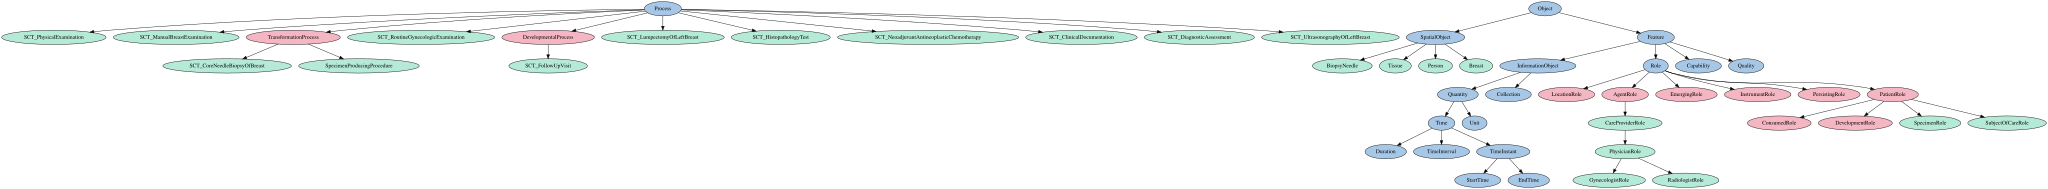

In [15]:
os.makedirs("dist", exist_ok=True)
mie.save(file="dist/mie-02.owl", format="rdfxml")
print("Saved dist/mie-02.owl")
print(f"  classes:                   {len(list(mie.classes()))}")
print(f"  individuals:               {len(list(mie.individuals()))}")
print(f"  object properties (local): {len(list(mie.object_properties()))}  ← still zero")
print(f"  imported ontologies:       {[o.base_iri for o in mie.imported_ontologies]}")

tree = get_color_tree([sulo, pro, mie])
display(tree)